In [ ]:
# Reciprocity Analysis
def analyze_reciprocity_patterns(data_cold, data_ir):
    """Analyze reciprocity - how models respond to partner behavior in previous rounds"""
    
    def calculate_reciprocity_metrics(data, condition_name):
        print(f"\n=== RECIPROCITY ANALYSIS: {condition_name.upper()} ===")
        
        reciprocity_data = []
        
        for entry in data:
            game_history = entry.get("game_history", {})
            
            # Need at least 2 rounds to analyze reciprocity
            if len(game_history) >= 2:
                for round_idx in range(2, 6):  # rounds 2-5
                    curr_run_key = f"run_{round_idx}"
                    prev_run_key = f"run_{round_idx-1}"
                    
                    if curr_run_key in game_history and prev_run_key in game_history:
                        curr_run = game_history[curr_run_key]
                        prev_run = game_history[prev_run_key]
                        
                        if curr_run and prev_run:  # Both rounds have data
                            # Previous round actions
                            prev_agent_0_action = 1 if prev_run["agent_0_answer"]["action"] == "A" else 0
                            prev_agent_1_action = 1 if prev_run["agent_1_answer"]["action"] == "A" else 0
                            
                            # Current round actions
                            curr_agent_0_action = 1 if curr_run["agent_0_answer"]["action"] == "A" else 0
                            curr_agent_1_action = 1 if curr_run["agent_1_answer"]["action"] == "A" else 0
                            
                            # Agent 0's response to Agent 1's previous action
                            reciprocity_data.append({
                                "model": entry["model_general_name_0"],
                                "partner_model": entry["model_general_name_1"],
                                "round": round_idx,
                                "partner_prev_action": prev_agent_1_action,
                                "my_curr_action": curr_agent_0_action,
                                "agent_role": 0
                            })
                            
                            # Agent 1's response to Agent 0's previous action
                            reciprocity_data.append({
                                "model": entry["model_general_name_1"],
                                "partner_model": entry["model_general_name_0"],
                                "round": round_idx,
                                "partner_prev_action": prev_agent_0_action,
                                "my_curr_action": curr_agent_1_action,
                                "agent_role": 1
                            })
        
        if not reciprocity_data:
            print("No reciprocity data available")
            return None
        
        reciprocity_df = pd.DataFrame(reciprocity_data)
        
        # Calculate reciprocity metrics by model
        reciprocity_summary = []
        
        for model in reciprocity_df["model"].unique():
            model_data = reciprocity_df[reciprocity_df["model"] == model]
            
            # Cooperation after partner cooperated
            coop_after_coop = model_data[model_data["partner_prev_action"] == 1]["my_curr_action"].mean() * 100
            
            # Cooperation after partner defected
            coop_after_defect = model_data[model_data["partner_prev_action"] == 0]["my_curr_action"].mean() * 100
            
            # Reciprocity score: difference between cooperation after cooperation vs defection
            reciprocity_score = coop_after_coop - coop_after_defect
            
            reciprocity_summary.append({
                "model": model,
                "coop_after_partner_coop": coop_after_coop,
                "coop_after_partner_defect": coop_after_defect,
                "reciprocity_score": reciprocity_score,
                "total_responses": len(model_data)
            })
        
        reciprocity_summary_df = pd.DataFrame(reciprocity_summary)
        
        print("Reciprocity patterns (how models respond to partner's previous action):")
        print("Positive reciprocity score = more cooperative after partner cooperates")
        print("Negative reciprocity score = more cooperative after partner defects")
        print()
        print(reciprocity_summary_df.round(1))
        
        return reciprocity_summary_df
    
    print("=== RECIPROCITY PATTERNS ANALYSIS ===")
    print("How models adjust their behavior based on partner's previous actions")
    
    reciprocity_cold = calculate_reciprocity_metrics(data_cold, "Cold")
    reciprocity_ir = calculate_reciprocity_metrics(data_ir, "Identity Reveal")
    
    # Visualization
    if reciprocity_cold is not None and reciprocity_ir is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Cold condition
        x_pos = np.arange(len(reciprocity_cold))
        ax1.bar(x_pos - 0.2, reciprocity_cold["coop_after_partner_coop"], 0.4, 
               label="After Partner Cooperated", alpha=0.7)
        ax1.bar(x_pos + 0.2, reciprocity_cold["coop_after_partner_defect"], 0.4, 
               label="After Partner Defected", alpha=0.7)
        ax1.set_xlabel("Model")
        ax1.set_ylabel("Cooperation Rate %")
        ax1.set_title("Reciprocity Patterns - Cold Condition")
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(reciprocity_cold["model"], rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Identity Reveal condition
        x_pos = np.arange(len(reciprocity_ir))
        ax2.bar(x_pos - 0.2, reciprocity_ir["coop_after_partner_coop"], 0.4, 
               label="After Partner Cooperated", alpha=0.7)
        ax2.bar(x_pos + 0.2, reciprocity_ir["coop_after_partner_defect"], 0.4, 
               label="After Partner Defected", alpha=0.7)
        ax2.set_xlabel("Model")
        ax2.set_ylabel("Cooperation Rate %")
        ax2.set_title("Reciprocity Patterns - Identity Reveal")
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(reciprocity_ir["model"], rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return reciprocity_cold, reciprocity_ir

reciprocity_cold, reciprocity_ir = analyze_reciprocity_patterns(data_cold, data_ir)

In [1]:
from collections import defaultdict
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

In [2]:
# Load data
folder_path_cold = "../results/multishot_cold/chickengame/"
folder_path_ir = "../results/multishot_ir/chickengame/"

def load_data(folder_path):
    data = []
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.endswith(".json"):
                file_path = os.path.join(root, filename)
                try:
                    with open(file_path, "r") as f:
                        entry = json.load(f)
                        data.append(entry)
                except json.JSONDecodeError as e:
                    print(f"Skipped invalid JSON: {file_path} ({e})")
    
    print(f"Loaded {len(data)} valid JSON result files from '{folder_path}' and its subfolders.")
    return data

data_cold = load_data(folder_path_cold)
data_ir = load_data(folder_path_ir)

Loaded 467 valid JSON result files from '../results/multishot_cold/chickengame/' and its subfolders.
Loaded 424 valid JSON result files from '../results/multishot_ir/chickengame/' and its subfolders.


In [3]:
def unordered_pair(a, b):
    return tuple(sorted([a, b]))

def process_by_round(data):
    # Dictionary to store results by round: {round_num: {model_pair: data}}
    rounds_data = defaultdict(lambda: defaultdict(lambda: {
        "model_0": None,
        "model_1": None,
        "rewards": {0: [], 1: []},
        "cooperation": {0: [], 1: []},
    }))
    
    # Aggregate data by round
    for entry in data:
        m0 = entry["model_general_name_0"]
        m1 = entry["model_general_name_1"]
        pair = unordered_pair(m0, m1)
        
        # Process each run in the game history
        game_history = entry.get("game_history", {})
        for run_key, run_data in game_history.items():
            if run_data:  # Skip empty runs
                # Extract round number from run_key (e.g., "run_1" -> 1)
                round_num = int(run_key.split("_")[1])
                
                rewards = [run_data["agent_0_reward"], run_data["agent_1_reward"]]
                actions = [
                    1 if run_data["agent_0_answer"]["action"] == "A" else 0,
                    1 if run_data["agent_1_answer"]["action"] == "A" else 0
                ]
        
                # Flip role if needed
                if pair == (m0, m1):
                    idx_0, idx_1 = 0, 1
                else:
                    idx_0, idx_1 = 1, 0
        
                rounds_data[round_num][pair]["model_0"] = pair[0]
                rounds_data[round_num][pair]["model_1"] = pair[1]
                rounds_data[round_num][pair]["rewards"][0].append(rewards[idx_0])
                rounds_data[round_num][pair]["rewards"][1].append(rewards[idx_1])
                rounds_data[round_num][pair]["cooperation"][0].append(actions[idx_0])
                rounds_data[round_num][pair]["cooperation"][1].append(actions[idx_1])
    
    # Convert to dataframes by round
    round_dataframes = {}
    for round_num in sorted(rounds_data.keys()):
        rows = []
        for (m0, m1), stats in rounds_data[round_num].items():
            def compute_stats(i):
                r = stats["rewards"][i]
                c = stats["cooperation"][i]
                return sum(r) / len(r), sum(c) / len(c) * 100
        
            avg_r0, coop_0 = compute_stats(0)
            avg_r1, coop_1 = compute_stats(1)
        
            rows.append({
                "model_0": m0,
                "model_1": m1,
                "avg_reward_0": avg_r0,
                "avg_reward_1": avg_r1,
                "cooperation_%_0": coop_0,
                "cooperation_%_1": coop_1,
                "n_matches": len(stats["rewards"][0])
            })
        
        round_dataframes[round_num] = pd.DataFrame(rows)
    
    return round_dataframes

rounds_cold = process_by_round(data_cold)
rounds_ir = process_by_round(data_ir)

print("Available rounds in cold data:", sorted(rounds_cold.keys()))
print("Available rounds in IR data:", sorted(rounds_ir.keys()))

Available rounds in cold data: [1, 2, 3, 4, 5]
Available rounds in IR data: [1, 2, 3, 4, 5]


In [4]:
def show_results_by_round(round_dataframes, condition_name):
    def create_heatmap(df_coop_summary, round_num):
        # Step 1: Create long-form data for all pair directions
        rows_long = []
        
        for _, row in df_coop_summary.iterrows():
            rows_long.append({
                "model_a": row["model_0"],
                "model_b": row["model_1"],
                "cooperation_percent": row["cooperation_%_0"]
            })
            rows_long.append({
                "model_a": row["model_1"],
                "model_b": row["model_0"],
                "cooperation_percent": row["cooperation_%_1"]
            })
        
        df_long = pd.DataFrame(rows_long)
        
        # Step 2: Pivot to matrix form
        heatmap_df = df_long.pivot_table(
            index="model_a",
            columns="model_b",
            values="cooperation_percent",
            aggfunc="mean"
        )
        
        return heatmap_df
    
    # Create subplots for each round
    rounds = sorted(round_dataframes.keys())
    n_rounds = len(rounds)
    
    fig, axes = plt.subplots(1, n_rounds, figsize=(5*n_rounds, 4))
    if n_rounds == 1:
        axes = [axes]
    
    for i, round_num in enumerate(rounds):
        heatmap_df = create_heatmap(round_dataframes[round_num], round_num)
        
        if i == n_rounds-1:
            sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="Blues", 
                       vmin=0, vmax=100.0, ax=axes[i], cbar_kws={'label': 'Cooperation %'})
        else:
            sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="Blues", 
                       vmin=0, vmax=100.0, ax=axes[i], cbar=False)
        axes[i].set_title(f"Round {round_num}")
        axes[i].set_ylabel("Cooperator" if i == 0 else "")
        axes[i].set_xlabel("Cooperatee")
    
    plt.suptitle(f"Cooperation % by Model Pair - {condition_name} (Multishot)", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Also print summary statistics for each round
    print(f"\n=== {condition_name} Summary by Round ===")
    for round_num in rounds:
        df = round_dataframes[round_num]
        avg_coop = (df["cooperation_%_0"].mean() + df["cooperation_%_1"].mean()) / 2
        print(f"Round {round_num}: Average cooperation = {avg_coop:.1f}%")
        print(df[["model_0", "model_1", "cooperation_%_0", "cooperation_%_1", "n_matches"]])
        print()

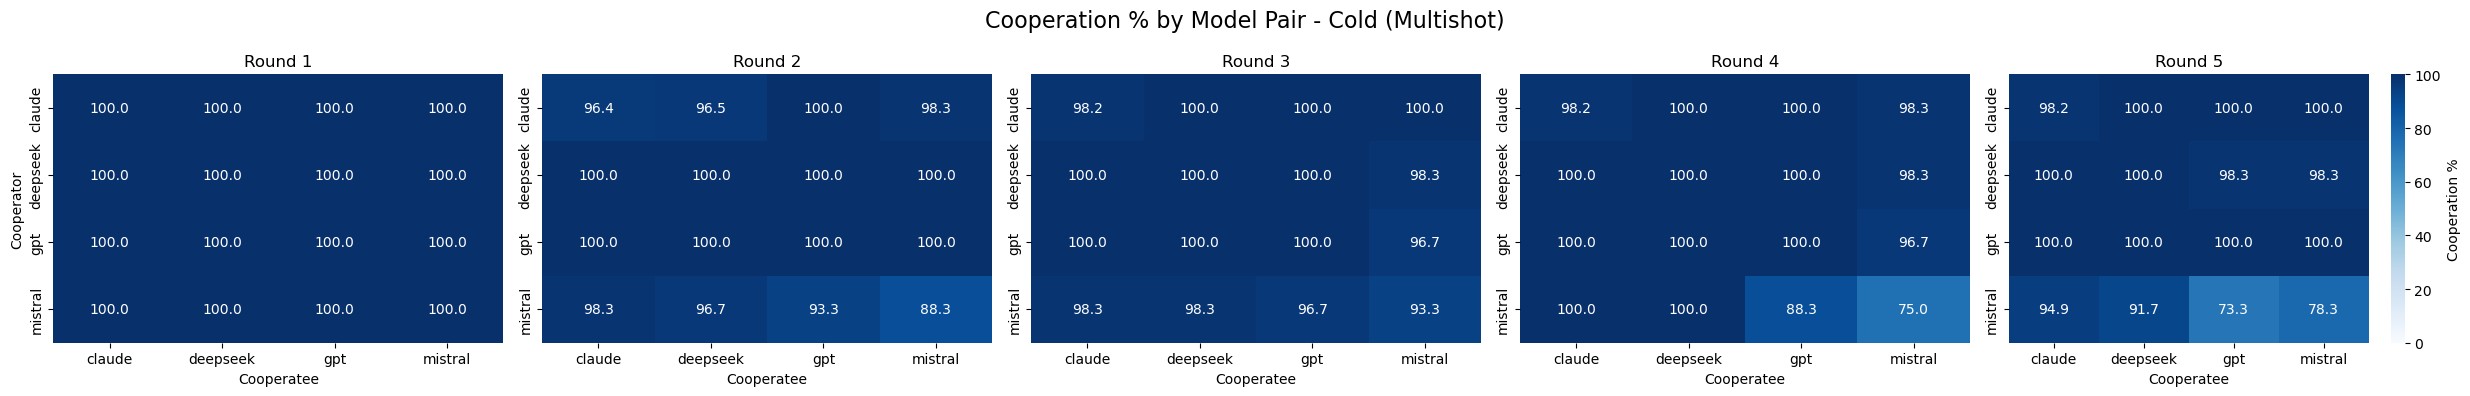


=== Cold Summary by Round ===
Round 1: Average cooperation = 100.0%
    model_0   model_1  cooperation_%_0  cooperation_%_1  n_matches
0    claude    claude            100.0            100.0         28
1    claude  deepseek            100.0            100.0         57
2    claude       gpt            100.0            100.0         58
3    claude   mistral            100.0            100.0         59
4  deepseek  deepseek            100.0            100.0         28
5  deepseek       gpt            100.0            100.0         58
6  deepseek   mistral            100.0            100.0         60
7       gpt       gpt            100.0            100.0         29
8       gpt   mistral            100.0            100.0         60
9   mistral   mistral            100.0            100.0         30

Round 2: Average cooperation = 97.6%
    model_0   model_1  cooperation_%_0  cooperation_%_1  n_matches
0    claude    claude        96.428571        96.428571         28
1    claude  deepseek 

In [5]:
show_results_by_round(rounds_cold, "Cold")

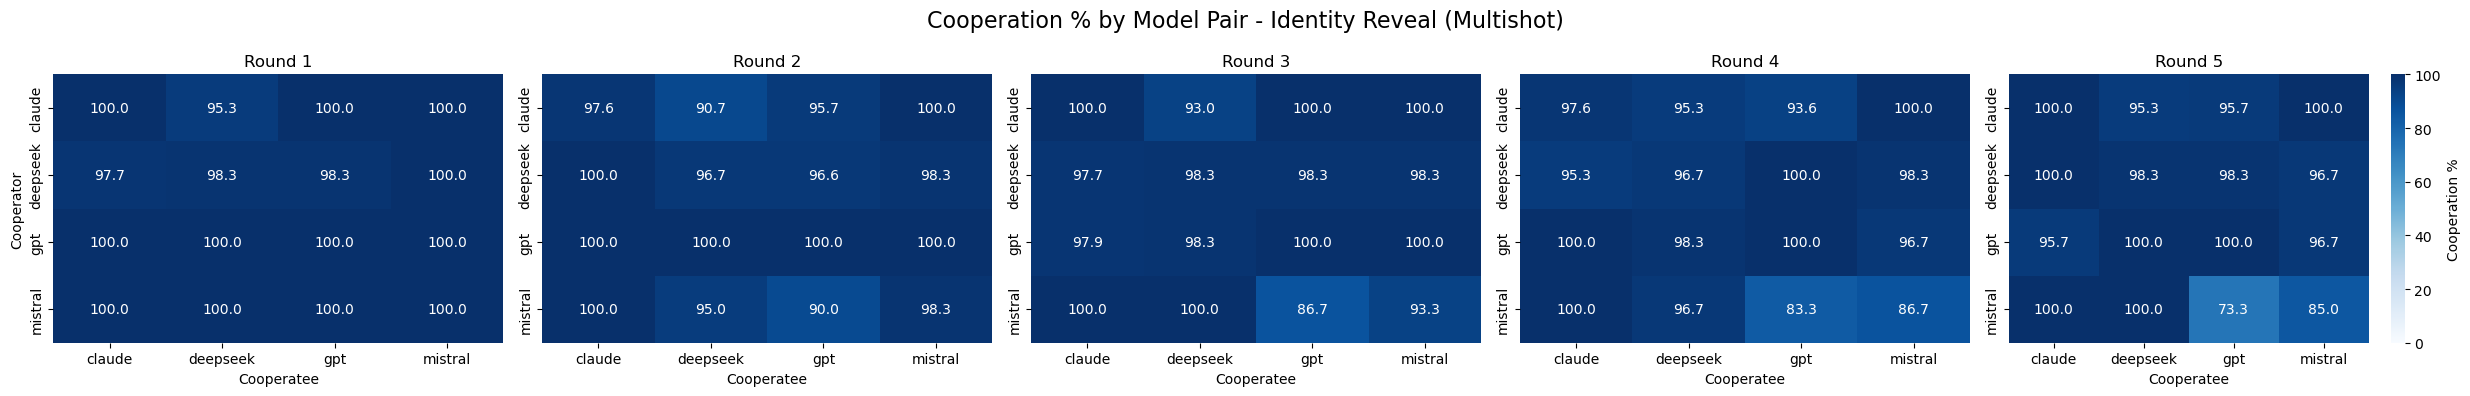


=== Identity Reveal Summary by Round ===
Round 1: Average cooperation = 99.4%
    model_0   model_1  cooperation_%_0  cooperation_%_1  n_matches
0    claude    claude       100.000000       100.000000         21
1    claude  deepseek        95.348837        97.674419         43
2    claude       gpt       100.000000       100.000000         47
3    claude   mistral       100.000000       100.000000         44
4  deepseek  deepseek        96.666667       100.000000         30
5  deepseek       gpt        98.305085       100.000000         59
6  deepseek   mistral       100.000000       100.000000         60
7       gpt       gpt       100.000000       100.000000         30
8       gpt   mistral       100.000000       100.000000         60
9   mistral   mistral       100.000000       100.000000         30

Round 2: Average cooperation = 97.6%
    model_0   model_1  cooperation_%_0  cooperation_%_1  n_matches
0    claude    claude        95.238095       100.000000         21
1    claude 

In [6]:
show_results_by_round(rounds_ir, "Identity Reveal")

In [ ]:
# Analyze cooperation trends across rounds
def analyze_cooperation_trends(rounds_cold, rounds_ir):
    def get_average_cooperation_by_round(round_dataframes):
        round_averages = {}
        for round_num in sorted(round_dataframes.keys()):
            df = round_dataframes[round_num]
            avg_coop = (df["cooperation_%_0"].mean() + df["cooperation_%_1"].mean()) / 2
            round_averages[round_num] = avg_coop
        return round_averages
    
    cold_trends = get_average_cooperation_by_round(rounds_cold)
    ir_trends = get_average_cooperation_by_round(rounds_ir)
    
    # Plot trends
    plt.figure(figsize=(10, 6))
    
    rounds = sorted(set(cold_trends.keys()) | set(ir_trends.keys()))
    cold_values = [cold_trends.get(r, None) for r in rounds]
    ir_values = [ir_trends.get(r, None) for r in rounds]
    
    plt.plot(rounds, cold_values, 'o-', label='Cold', linewidth=2, markersize=8)
    plt.plot(rounds, ir_values, 's-', label='Identity Reveal', linewidth=2, markersize=8)
    
    plt.xlabel('Round Number')
    plt.ylabel('Average Cooperation %')
    plt.title('Cooperation Trends Across Rounds')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rounds)
    plt.ylim(0, 100)
    
    # Add trend lines
    if len(rounds) > 1:
        z_cold = np.polyfit(rounds, [v for v in cold_values if v is not None], 1)
        z_ir = np.polyfit(rounds, [v for v in ir_values if v is not None], 1)
        plt.plot(rounds, np.poly1d(z_cold)(rounds), '--', alpha=0.7, color='blue')
        plt.plot(rounds, np.poly1d(z_ir)(rounds), '--', alpha=0.7, color='orange')
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== Cooperation Trends ===")
    print("Cold condition:")
    for round_num, avg_coop in cold_trends.items():
        print(f"  Round {round_num}: {avg_coop:.1f}%")
    
    print("\nIdentity Reveal condition:")
    for round_num, avg_coop in ir_trends.items():
        print(f"  Round {round_num}: {avg_coop:.1f}%")

analyze_cooperation_trends(rounds_cold, rounds_ir)

In [ ]:
# Advanced Analysis Functions
def analyze_cooperation_stability(rounds_cold, rounds_ir):
    """Analyze cooperation stability across rounds for each model pair"""
    
    def calculate_stability_metrics(round_dataframes):
        stability_data = []
        
        # Get all unique model pairs across all rounds
        all_pairs = set()
        for round_df in round_dataframes.values():
            for _, row in round_df.iterrows():
                pair = tuple(sorted([row["model_0"], row["model_1"]]))
                all_pairs.add(pair)
        
        for pair in all_pairs:
            pair_cooperation_rates = []
            rounds_with_data = []
            
            for round_num in sorted(round_dataframes.keys()):
                round_df = round_dataframes[round_num]
                # Find this pair in current round
                pair_rows = round_df[
                    ((round_df["model_0"] == pair[0]) & (round_df["model_1"] == pair[1])) |
                    ((round_df["model_0"] == pair[1]) & (round_df["model_1"] == pair[0]))
                ]
                
                if not pair_rows.empty:
                    row = pair_rows.iloc[0]
                    avg_coop = (row["cooperation_%_0"] + row["cooperation_%_1"]) / 2
                    pair_cooperation_rates.append(avg_coop)
                    rounds_with_data.append(round_num)
            
            if len(pair_cooperation_rates) >= 2:  # Need at least 2 data points for variance
                stability_data.append({
                    "model_pair": f"{pair[0]}-{pair[1]}",
                    "mean_cooperation": np.mean(pair_cooperation_rates),
                    "std_cooperation": np.std(pair_cooperation_rates),
                    "min_cooperation": np.min(pair_cooperation_rates),
                    "max_cooperation": np.max(pair_cooperation_rates),
                    "cooperation_range": np.max(pair_cooperation_rates) - np.min(pair_cooperation_rates),
                    "rounds_analyzed": len(pair_cooperation_rates),
                    "cooperation_trend": np.polyfit(rounds_with_data, pair_cooperation_rates, 1)[0] if len(pair_cooperation_rates) > 1 else 0
                })
        
        return pd.DataFrame(stability_data)
    
    print("=== COOPERATION STABILITY ANALYSIS ===\n")
    
    stability_cold = calculate_stability_metrics(rounds_cold)
    stability_ir = calculate_stability_metrics(rounds_ir)
    
    print("COLD CONDITION:")
    print("Model pairs ranked by cooperation stability (low std = more stable):")
    print(stability_cold.sort_values("std_cooperation")[["model_pair", "mean_cooperation", "std_cooperation", "cooperation_range", "cooperation_trend"]].round(2))
    
    print("\nIDENTITY REVEAL CONDITION:")
    print("Model pairs ranked by cooperation stability (low std = more stable):")
    print(stability_ir.sort_values("std_cooperation")[["model_pair", "mean_cooperation", "std_cooperation", "cooperation_range", "cooperation_trend"]].round(2))
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    if not stability_cold.empty:
        ax1.scatter(stability_cold["mean_cooperation"], stability_cold["std_cooperation"], alpha=0.7)
        for i, row in stability_cold.iterrows():
            ax1.annotate(row["model_pair"], (row["mean_cooperation"], row["std_cooperation"]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        ax1.set_xlabel("Mean Cooperation %")
        ax1.set_ylabel("Cooperation Std Dev")
        ax1.set_title("Cold Condition: Stability vs Cooperation")
        ax1.grid(True, alpha=0.3)
    
    if not stability_ir.empty:
        ax2.scatter(stability_ir["mean_cooperation"], stability_ir["std_cooperation"], alpha=0.7, color='orange')
        for i, row in stability_ir.iterrows():
            ax2.annotate(row["model_pair"], (row["mean_cooperation"], row["std_cooperation"]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        ax2.set_xlabel("Mean Cooperation %")
        ax2.set_ylabel("Cooperation Std Dev")
        ax2.set_title("Identity Reveal: Stability vs Cooperation")
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return stability_cold, stability_ir

stability_cold, stability_ir = analyze_cooperation_stability(rounds_cold, rounds_ir)

In [ ]:
# Learning Patterns Analysis
def analyze_learning_patterns(rounds_cold, rounds_ir):
    """Analyze how cooperation changes across rounds to identify learning patterns"""
    
    def calculate_learning_metrics(round_dataframes, condition_name):
        print(f"\n=== LEARNING PATTERNS: {condition_name.upper()} ===")
        
        # Get all unique models
        all_models = set()
        for round_df in round_dataframes.values():
            all_models.update(round_df["model_0"].unique())
            all_models.update(round_df["model_1"].unique())
        
        model_learning = {}
        
        for model in all_models:
            model_cooperation_by_round = {}
            
            for round_num in sorted(round_dataframes.keys()):
                round_df = round_dataframes[round_num]
                
                # Get cooperation rates for this model in this round
                model_coop_rates = []
                
                # As model_0
                model_0_rows = round_df[round_df["model_0"] == model]
                model_coop_rates.extend(model_0_rows["cooperation_%_0"].tolist())
                
                # As model_1
                model_1_rows = round_df[round_df["model_1"] == model]
                model_coop_rates.extend(model_1_rows["cooperation_%_1"].tolist())
                
                if model_coop_rates:
                    model_cooperation_by_round[round_num] = np.mean(model_coop_rates)
            
            if len(model_cooperation_by_round) >= 2:
                rounds = sorted(model_cooperation_by_round.keys())
                cooperation_values = [model_cooperation_by_round[r] for r in rounds]
                
                # Calculate learning trend
                if len(rounds) > 1:
                    slope, intercept = np.polyfit(rounds, cooperation_values, 1)
                    learning_direction = "Increasing" if slope > 0.5 else "Decreasing" if slope < -0.5 else "Stable"
                else:
                    slope = 0
                    learning_direction = "Insufficient data"
                
                model_learning[model] = {
                    "rounds": rounds,
                    "cooperation_values": cooperation_values,
                    "learning_slope": slope,
                    "learning_direction": learning_direction,
                    "initial_cooperation": cooperation_values[0],
                    "final_cooperation": cooperation_values[-1],
                    "cooperation_change": cooperation_values[-1] - cooperation_values[0]
                }
                
                print(f"{model:15} | Initial: {cooperation_values[0]:5.1f}% | Final: {cooperation_values[-1]:5.1f}% | Change: {cooperation_values[-1] - cooperation_values[0]:+5.1f}% | {learning_direction}")
        
        return model_learning
    
    print("=== LEARNING PATTERNS ANALYSIS ===")
    print("How each model's cooperation behavior changes across rounds")
    
    learning_cold = calculate_learning_metrics(rounds_cold, "Cold")
    learning_ir = calculate_learning_metrics(rounds_ir, "Identity Reveal")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Cold condition
    for model, data in learning_cold.items():
        ax1.plot(data["rounds"], data["cooperation_values"], 'o-', label=model, linewidth=2, markersize=6)
    ax1.set_xlabel("Round Number")
    ax1.set_ylabel("Average Cooperation %")
    ax1.set_title("Learning Patterns - Cold Condition")
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 100)
    
    # Identity Reveal condition
    for model, data in learning_ir.items():
        ax2.plot(data["rounds"], data["cooperation_values"], 's-', label=model, linewidth=2, markersize=6)
    ax2.set_xlabel("Round Number")
    ax2.set_ylabel("Average Cooperation %")
    ax2.set_title("Learning Patterns - Identity Reveal")
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    return learning_cold, learning_ir

learning_cold, learning_ir = analyze_learning_patterns(rounds_cold, rounds_ir)